# Advanced: Adjust simulation to ERA5 Atmospheric Profiles

Integration of ERA5 reanalysis data for realistic atmospheric profile input to radiative transfer simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os

# we use the GCSFileSystem to access the ERA5 data stored in Google Cloud Storage
gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')
#full_era5.to_netcdf('../data/era5_6h_128x64.nc', engine='h5netcdf')

In [2]:
full_era5['specific_humidity'].units

'kg kg**-1'

In [3]:
era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})

## manually add ozone profile if not present
if 'o3' not in era5_to_sim.data_vars:
    # Use a constant profile for ozone, e.g., 300 DU
    # Convert DU to number density (1 DU = 2.687e19 molecules/m^2)
    # Assume a standard atmosphere for conversion
    altitude_km = era5_to_sim['z'] / 1000.0  # Convert geopotential height to km
    o3_profile = xr.DataArray(
        data=300e-6 * 2.687e19 * np.exp(-altitude_km / 8.5),  # Example exponential decay
        dims=era5_to_sim['z'].dims,
        coords=era5_to_sim['z'].coords,
        name='o3'
    )
    era5_to_sim = era5_to_sim.assign(o3=o3_profile)


In [4]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 7

# stationary simulation at constant altitude, latitude, and longitude but with varying time
# be aware that the max altitude needs to be lower than the max altitude in the ERA5 data

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-04T12:00:00', periods=N_timesteps, freq='d'),
        'latitude' : ('time', [51.336466] * N_timesteps),
        'longitude' : ('time', [12.375255] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 20, 1)),
    }
)



# load the ERA5 data for the specified space and time // this didn't make it faster...
ds_era5_local = era5_to_sim.sel(
    latitude=ds['latitude'],
    longitude=ds['longitude'],
    valid_time=ds['time'],
    method='nearest'
).load()

ds_era5_local = ds_era5_local.assign_coords(
    z = ds_era5_local['z'] / 9.81 / 1e3 # Convert geopotential height to km
)

In [5]:
ds_era5_local['q']

<xarray.DataArray 'q' (time: 7, pressure_level: 13)> Size: 364B
array([[2.8676568e-06, 2.5565803e-06, 3.0835010e-06, 5.8590431e-06,
        1.2743219e-05, 3.8091366e-05, 1.5474987e-04, 2.9634757e-04,
        1.5267773e-04, 8.6384622e-04, 3.0563821e-03, 3.1681198e-03,
        3.3865625e-03],
       [2.7966232e-06, 2.4962414e-06, 6.1633405e-06, 3.5409607e-06,
        1.0503968e-05, 4.8397473e-05, 1.8732369e-04, 4.0735869e-04,
        5.8552373e-04, 3.5656689e-04, 1.7749876e-03, 3.0556205e-03,
        3.3509270e-03],
       [2.9184396e-06, 2.5781289e-06, 4.0301284e-06, 3.7055468e-06,
        1.1095025e-05, 3.6624351e-05, 1.0045036e-04, 3.6092123e-04,
        4.0963199e-04, 3.4516121e-04, 2.3557360e-03, 3.4433771e-03,
        3.8883972e-03],
       [2.9412422e-06, 2.6209827e-06, 3.7388875e-06, 3.9125443e-06,
        1.0470353e-05, 2.5458587e-05, 7.3592826e-05, 1.6372309e-04,
        3.0635032e-04, 1.0712214e-03, 3.6903901e-03, 4.3159123e-03,
        4.6783495e-03],
       [2.8902632e-06, 2.7319900e-06, 3.2895673e-06, 5.0870331e-06,
        8.7571425e-06, 1.7947781e-05, 8.3993073e-05, 1.4821657e-04,
        1.5575161e-04, 5.3997064e-04, 2.6608345e-03, 3.1155478e-03,
        3.5260792e-03],
       [2.9120638e-06, 2.5538739e-06, 3.4335305e-06, 9.6101885e-06,
        1.3702806e-05, 2.5556958e-05, 9.8668388e-05, 2.5239857e-04,
        4.6557368e-04, 1.6773735e-03, 4.0466678e-03, 4.2733476e-03,
        4.6208766e-03],
       [2.7882352e-06, 2.5623781e-06, 4.4003768e-06, 1.0968143e-05,
        3.1802247e-05, 8.9663707e-05, 2.8880220e-04, 2.9637237e-04,
        1.5368409e-04, 5.1714375e-04, 4.3268320e-03, 4.6642907e-03,
        4.9807848e-03]], dtype=float32)
Coordinates:
    z               (time, pressure_level) float32 364B 20.34 16.01 ... 0.2012
    latitude        (time) float64 56B 50.0 50.0 50.0 50.0 50.0 50.0 50.0
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
    longitude       (time) float64 56B 11.25 11.25 11.25 11.25 11.25 11.25 11.25
    valid_time      (time) datetime64[ns] 56B 2020-04-04T12:00:00 ... 2020-04...
  * time            (time) datetime64[ns] 56B 2020-04-04T12:00:00 ... 2020-04...
Attributes:
    long_name:      Specific humidity
    short_name:     q
    standard_name:  specific_humidity
    units:          kg kg**-1

In [6]:
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,
    era5_atmosphere=ds_era5_local,  # Use the local ERA5 data
)

2025-12-12 21:39:20,705 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 13 pressure levels
2025-12-12 21:39:20,706 - pyradtran.interface - INFO - Altitude found as coordinate - using 20 levels for zout: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
2025-12-12 21:39:20,708 - pyradtran.interface - INFO - Preparing 7 simulations from input dataset with dims ['time']
2025-12-12 21:39:20,709 - pyradtran.interface - INFO - Creating ERA5 atmosphere files for simulation points...
2025-12-12 21:39:20,711 - pyradtran.interface - DEBUG - Created/Found ERA5 atmosphere file for 20200404_120000_51.34_12.38: work/era5_atmospheres/era5_atm_20200404_120000_51.34_12.38.dat
2025-12-12 21:39:20,712 - pyradtran.interface - DEBUG - Created/Found ERA5 atmosphere file for 20200405_120000_51.34_12.38: work/era5_atmospheres/era5_atm_20200405_120000_51.34_12.38.dat
2025-12-12 21:39:20,714 - pyradtran.interface - DEBUG - Created/Found ERA5 atmosphere file for 20200406_120000_

2025-12-12 21:39:21,316 - pyradtran.core - ERROR - Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,320 - pyradtran.core - ERROR - Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,325 - pyradtran.interface - ERROR - Single simulation failed for point 20200406_120000_51.34_12.38_2: Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,323 - pyradtran.core - ERROR - Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,325 - pyradtran.core - ERROR - Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,332 - pyradtran.core - ERROR - Simulation failed: cannot access local variable 'h2o_unit' where it is not associated with a value
2025-12-12 21:39:21,342 - pyr

PyRadtranError: All simulations failed - no valid results produced

## Distance between Requested Point and Nearest ERA5 Point

Compare the distance between the requested point and the nearest ERA5 point with the `haversine` function.

In [ ]:

def haversine(lon1, lat1, lon2, lat2):
    # convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [ ]:
distances = haversine(
    ds['longitude'].values,
    ds['latitude'].values,
    ds_era5_local['longitude'].values,
    ds_era5_local['latitude'].values
)

print(f"Distances to nearest ERA5 point: {distances} km")

Distances to nearest ERA5 point: [168.43944596 168.43944596 168.43944596 168.43944596 168.43944596
 168.43944596 168.43944596] km


## Investigating the simulation results

As the simulation results are stored in an xarray dataset, you can use the xarray plotting capabilities to visualize the results.

In [ ]:
ds_era5_local.t

<xarray.DataArray 't' (time: 7, pressure_level: 13)> Size: 364B
array([[214.94797, 213.31366, 213.96211, 207.48996, 214.59138, 223.99263,
        239.40698, 249.9818 , 260.3134 , 264.53793, 272.06534, 278.6144 ,
        283.88516],
       [210.4976 , 211.66722, 209.5003 , 205.55516, 217.01645, 227.01665,
        244.01733, 257.12854, 264.68958, 271.795  , 276.67307, 281.91183,
        287.3244 ],
       [209.58752, 213.16273, 212.3668 , 206.4207 , 217.14804, 226.42052,
        243.7111 , 256.3409 , 265.92407, 272.59778, 280.58215, 285.91367,
        291.2678 ],
       [211.64577, 212.78586, 212.5107 , 207.67154, 216.19234, 225.54921,
        241.31699, 254.38576, 264.21228, 270.64276, 280.13644, 286.3661 ,
        291.9816 ],
       [212.60658, 212.82393, 213.08173, 208.53116, 216.4376 , 225.60712,
        240.46614, 254.17343, 265.34637, 271.66043, 280.49554, 286.93924,
        292.4186 ],
       [211.49678, 212.16919, 213.97028, 209.488  , 215.72455, 225.37729,
        241.56468, 253.70395, 263.51636, 269.10303, 280.97543, 287.0054 ,
        292.39542],
       [211.61923, 211.63982, 212.72069, 206.54765, 216.21503, 226.43425,
        242.22891, 255.24002, 264.82718, 270.5359 , 278.62946, 285.31906,
        290.76028]], dtype=float32)
Coordinates:
    z               (time, pressure_level) float32 364B 20.34 16.01 ... 0.2012
    latitude        (time) float64 56B 50.0 50.0 50.0 50.0 50.0 50.0 50.0
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
    longitude       (time) float64 56B 11.25 11.25 11.25 11.25 11.25 11.25 11.25
    valid_time      (time) datetime64[ns] 56B 2020-04-04T12:00:00 ... 2020-04...
  * time            (time) datetime64[ns] 56B 2020-04-04T12:00:00 ... 2020-04...
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K

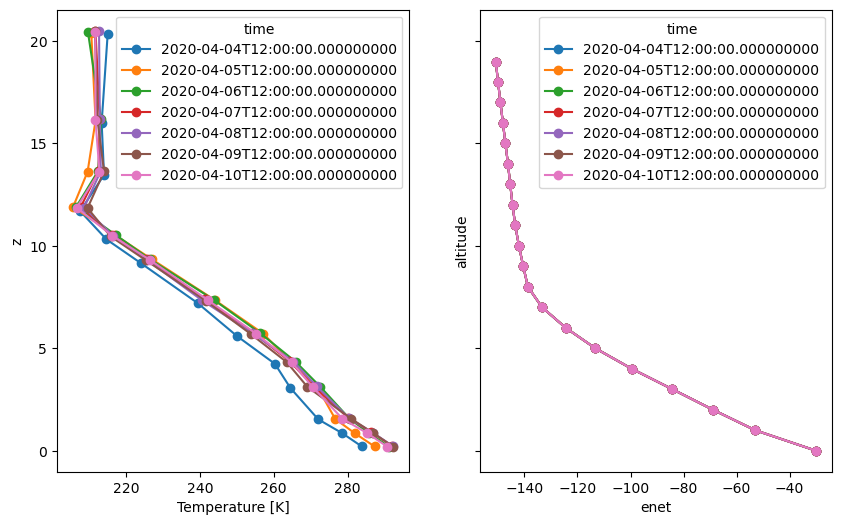

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

ds_sim.enet.plot(
    hue='time',
    y='altitude',
    marker='o',
    ax=ax[1],
)

ds_era5_local.t.plot(
    hue='time',
    y='z',
    marker='o',
    ax=ax[0],
)